# Análisis de datos
### Nancy Armua | Brian Talavera 

## Preparación de ambiente 

In [2]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns


### Fuente del dataset

Dataset recorridos Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/ff671909-6860-4398-8d0a-8f2389cb2780/download

Dataset ususarios Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/edb5ed27-8506-43f0-88ce-3e5c0aa1a406/download


#### 1. Cargar datos desde un archivo CSV a un df de Pandas

In [3]:
path = "./dataset/"

df_recorridos = pd.read_csv(path + "trips_2023.csv")
df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


/tmp/ipykernel_27584/392836254.py:4: DtypeWarning: Columns (0: edad_usuario) have mixed types. Specify dtype option on import or set low_memory=False.
  df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


** A revisar: para el dataset de usuarios, edar_usuario aparentemente contiene datos mixtos.

## Exploración y comprensión de los datos
### 1. Primeras filas de cada dataset


In [4]:
# Mostrar las primeras 5 filas de cada dataset
df_recorridos.head(5)


,Unnamed: 0,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género
0,1,17910696BAEcobici,"1,848",2023-04-24 10:30:10,358BAEcobici,249 - Balbín,2519 Conesa,-58.465586,-34.561486,2023-04-24 11:00:58,278BAEcobici,233 - MONROE,2519 Superi,-58.469813,-34.564122,861866BAEcobici,ICONIC,MALE
1,2,17600256BAEcobici,288,2023-03-22 17:40:55,444BAEcobici,061 - Ministerio de Economia,"Balcarce e Yrigoyen, Hipolito Av.",-58.370716,-34.608936,2023-03-22 17:45:43,3BAEcobici,003 - ADUANA,Moreno & Azopardo,-58.368174,-34.611102,217525BAEcobici,ICONIC,FEMALE
2,3,17255670BAEcobici,"1,103",2023-02-15 23:12:22,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,2023-02-15 23:30:45,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,954201BAEcobici,ICONIC,MALE
3,4,17996972BAEcobici,"1,165",2023-05-03 11:00:20,273BAEcobici,223 - GAINZA,"494 Gainza, Martin De, Gral.",-58.446751,-34.616758,2023-05-03 11:19:45,367BAEcobici,287 - Belaustegui,"Belaustegui, Luis, Dr. 2890",-58.477209,-34.616212,179414BAEcobici,ICONIC,MALE
4,5,17148836BAEcobici,378,2023-02-06 06:50:58,65BAEcobici,065 - Julián Álvarez,3822 Guemes,-58.415787,-34.587312,2023-02-06 06:57:16,14BAEcobici,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,8098BAEcobici,ICONIC,MALE


In [5]:
df_usuarios.head(5)

,ID_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta,Customer.Has.Dni..Yes...No.
0,1083476,MALE,20,2023-12-31,19:24:57,Yes
1,1083080,FEMALE,18,2023-12-31,00:05:03,Yes
2,1083163,OTHER,27,2023-12-31,10:16:12,No
3,1083435,MALE,24,2023-12-31,17:42:11,Yes
4,1083376,OTHER,32,2023-12-31,16:16:15,No


#### Descripción del dataset de usuarios


| Variable | Descripción |
| --- | --- |
| `ID_usuario` | Identificador único del usuario |
| `genero_usuario` | Género autopercibido declarado por el usuario (`MALE`, `FEMALE`, `OTHER`) |
| `edad_usuario` | Edad del usuario en años |
| `fecha_alta` | Fecha de alta del usuario en el sistema |
| `hora_alta` | Hora de alta del usuario en el sistema |
| `Customer.Has.Dni..Yes...No.` | Indica si el usuario cuenta con DNI registrado (`Yes`/`No`) |


#### Descripción del dataset de recorridos

| Variable | Descripción |
| --- | --- |
| `Id_recorrido` | Identificador único del recorrido |
| `duracion_recorrido` | Duración del recorrido (en segundos) |
| `fecha_origen_recorrido` | Fecha y hora de inicio del recorrido |
| `id_estacion_origen` | Identificador de la estación de origen |
| `nombre_estacion_origen` | Nombre de la estación de origen |
| `direccion_estacion_origen` | Dirección de la estación de origen |
| `long_estacion_origen` | Longitud geográfica de la estación de origen |
| `lat_estacion_origen` | Latitud geográfica de la estación de origen |
| `fecha_destino_recorrido` | Fecha y hora de finalización del recorrido |
| `id_estacion_destino` | Identificador de la estación de destino |
| `nombre_estacion_destino` | Nombre de la estación de destino |
| `direccion_estacion_destino` | Dirección de la estación de destino |
| `long_estacion_destino` | Longitud geográfica de la estación de destino |
| `lat_estacion_destino` | Latitud geográfica de la estación de destino |
| `id_usuario` | Identificador del usuario que realizó el recorrido |
| `modelo_bicicleta` | Modelo de la bicicleta utilizada (`ICONIC`, `FIT`) |
| `género` | Género autopercibido del usuario (`MALE`, `FEMALE`, `OTHER`) |


### 2. Diagnóstico inicial: dimensiones, tipos de datos, duplicados y valores faltantes


In [6]:
for nombre, df in [("usuarios", df_usuarios), ("recorridos", df_recorridos)]:
    print(f"\n===== {nombre.upper()} =====")
    print("Dimensiones (filas, columnas):", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nDuplicados exactos:", df.duplicated().sum())
    print("\nValores nulos por columna:")
    print(df.isnull().sum())



===== USUARIOS =====
Dimensiones (filas, columnas): (136066, 6)

Tipos de datos:
ID_usuario                      int64
genero_usuario                    str
edad_usuario                   object
fecha_alta                        str
hora_alta                         str
Customer.Has.Dni..Yes...No.       str
dtype: object

Duplicados exactos: 0

Valores nulos por columna:
ID_usuario                     0
genero_usuario                 0
edad_usuario                   0
fecha_alta                     0
hora_alta                      0
Customer.Has.Dni..Yes...No.    0
dtype: int64

===== RECORRIDOS =====
Dimensiones (filas, columnas): (2622331, 18)

Tipos de datos:
Unnamed: 0                      int64
Id_recorrido                      str
duracion_recorrido                str
fecha_origen_recorrido            str
id_estacion_origen                str
nombre_estacion_origen            str
direccion_estacion_origen         str
long_estacion_origen          float64
lat_estacion_origen     

#### Número de observaciones y de variables (consigna, punto 2)


In [7]:
for nombre, df in [("usuarios", df_usuarios), ("recorridos", df_recorridos)]:
    print(f"{nombre}: {df.shape[0]:,} observaciones y {df.shape[1]} variables")


usuarios: 136,066 observaciones y 6 variables
recorridos: 2,622,331 observaciones y 18 variables


### 3. Inspeccionar y corregir tipos de datos

Como se vio en clase, Pandas no siempre asigna el dtype correcto al importar un CSV: hay que
revisar cada variable y asignar el tipo que le corresponde (numérica, categórica u fecha).


In [8]:
df_recorridos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2622331 entries, 0 to 2622330
Data columns (total 18 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Unnamed: 0                  int64  
 1   Id_recorrido                str    
 2   duracion_recorrido          str    
 3   fecha_origen_recorrido      str    
 4   id_estacion_origen          str    
 5   nombre_estacion_origen      str    
 6   direccion_estacion_origen   str    
 7   long_estacion_origen        float64
 8   lat_estacion_origen         float64
 9   fecha_destino_recorrido     str    
 10  id_estacion_destino         str    
 11  nombre_estacion_destino     str    
 12  direccion_estacion_destino  str    
 13  long_estacion_destino       float64
 14  lat_estacion_destino        float64
 15  id_usuario                  str    
 16  modelo_bicicleta            str    
 17  género                      str    
dtypes: float64(4), int64(1), str(13)
memory usage: 842.3 MB


In [9]:
# duracion_recorrido convertir a number
df_recorridos['duracion_recorrido'] = pd.to_numeric(df_recorridos['duracion_recorrido'], errors="coerce")

# remover acento para facilitar tipado y luego convertir genero
df_recorridos = df_recorridos.rename(columns={"género": "genero"})
genero_category = CategoricalDtype(categories=["MALE", "FEMALE", "OTHER"])
df_recorridos["genero"] = df_recorridos["genero"].astype(genero_category)

# definir categoria de modelos de bicicleta
modelos_bicicletas_category = CategoricalDtype(categories=["ICONIC", "FIT"]) 
df_recorridos["modelo_bicicleta"] = df_recorridos["modelo_bicicleta"].astype(modelos_bicicletas_category)

# fechas
df_recorridos["fecha_origen_recorrido"] = pd.to_datetime(df["fecha_origen_recorrido"])
df_recorridos["fecha_destino_recorrido"] = pd.to_datetime(df["fecha_destino_recorrido"])

# otras categorias
df_recorridos["id_estacion_destino"] = df_recorridos["id_estacion_destino"].astype("category")
df_recorridos["id_estacion_origen"] = df_recorridos["id_estacion_origen"].astype("category")
df_recorridos["id_usuario"] = df_recorridos["id_usuario"].astype("category")



In [10]:
df_recorridos.dtypes


Unnamed: 0                             int64
Id_recorrido                             str
duracion_recorrido                   float64
fecha_origen_recorrido        datetime64[us]
id_estacion_origen                  category
nombre_estacion_origen                   str
direccion_estacion_origen                str
long_estacion_origen                 float64
lat_estacion_origen                  float64
fecha_destino_recorrido       datetime64[us]
id_estacion_destino                 category
nombre_estacion_destino                  str
direccion_estacion_destino               str
long_estacion_destino                float64
lat_estacion_destino                 float64
id_usuario                          category
modelo_bicicleta                    category
genero                              category
dtype: object

In [11]:
df_usuarios.dtypes

ID_usuario                      int64
genero_usuario                    str
edad_usuario                   object
fecha_alta                        str
hora_alta                         str
Customer.Has.Dni..Yes...No.       str
dtype: object

In [12]:
# --- df_usuarios: fecha a datetime, categórica nominal y edad a numérica ---
df_usuarios["fecha_alta"] = pd.to_datetime(df_usuarios["fecha_alta"])
df_usuarios["genero_usuario"] = df_usuarios["genero_usuario"].astype(genero_category)

# edad_usuario llega como texto; los valores no numéricos quedan como NaN (a cuantificar
# en la Tarea de valores faltantes/errores)
df_usuarios["edad_usuario"] = pd.to_numeric(df_usuarios["edad_usuario"], errors="coerce")

# renombrar y definir tipo para categoria DNI
dni_category = CategoricalDtype(categories=["Yes", "No"])
df_usuarios = df_usuarios.rename(columns={"Customer.Has.Dni..Yes...No.": "dni"})
df_usuarios["dni"] = df_usuarios["dni"].astype(dni_category)

# edad
df_usuarios["edad_usuario"] = df_usuarios["edad_usuario"].astype("Int64")


df_usuarios.dtypes


ID_usuario                 int64
genero_usuario          category
edad_usuario               Int64
fecha_alta        datetime64[us]
hora_alta                    str
dni                     category
dtype: object

### 4. Estadística descriptiva general (características principales del dataset)


In [13]:
print("Estadística descriptiva - variables numéricas (df_recorridos):\n")
df_recorridos.describe()


Estadística descriptiva - variables numéricas (df_recorridos):



,Unnamed: 0,duracion_recorrido,fecha_origen_recorrido,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,long_estacion_destino,lat_estacion_destino
count,2.622331e+06,1.410096e+06,2622331,2.622331e+06,2.622331e+06,2622331,2.622329e+06,2.622329e+06
mean,1.311166e+06,5.977490e+02,2023-07-01 12:17:09.035299,-5.841950e+01,-3.459812e+01,2023-07-01 12:40:09.648620,-5.841985e+01,-3.459819e+01
min,1.000000e+00,6.100000e+01,2023-01-01 00:06:08,-5.852602e+01,-3.468176e+01,2023-01-01 00:12:22,-5.852602e+01,-3.468176e+01
25%,6.555835e+05,4.270000e+02,2023-03-23 19:14:48.500000,-5.844507e+01,-3.461495e+01,2023-03-23 19:36:33,-5.844600e+01,-3.461533e+01
50%,1.311166e+06,5.960000e+02,2023-06-30 16:16:48,-5.841601e+01,-3.460014e+01,2023-06-30 16:36:21,-5.841601e+01,-3.459978e+01
75%,1.966748e+06,7.780000e+02,2023-10-08 14:28:56,-5.838997e+01,-3.458373e+01,2023-10-08 15:07:11,-5.839009e+01,-3.458332e+01
max,2.622331e+06,9.990000e+02,2023-12-31 23:59:23,-5.835547e+01,-3.453669e+01,2024-01-02 14:35:15,-5.835547e+01,-3.453669e+01
std,7.570019e+05,2.221230e+02,NaN,3.730778e-02,2.285398e-02,NaN,3.757239e-02,2.324947e-02


In [14]:
print("Estadística descriptiva - variables categóricas (df_recorridos):\n")
# count = cant. de datos no nulos | unique = cant. de categorías | top = categoría más frecuente | freq = su frecuencia
df_recorridos.describe(include="category")


Estadística descriptiva - variables categóricas (df_recorridos):



,id_estacion_origen,id_estacion_destino,id_usuario,modelo_bicicleta,genero
count,2622331,2622329,2622331,2622331,2610365
unique,364,365,212068,2,3
top,175BAEcobici,14BAEcobici,668737BAEcobici,FIT,MALE
freq,35834,31863,1122,1655149,1580419


In [15]:
print("Estadística descriptiva - variables numéricas (df_usuarios):\n")
df_usuarios.describe()


Estadística descriptiva - variables numéricas (df_usuarios):



,ID_usuario,edad_usuario,fecha_alta
count,1.360660e+05,136065.0,136066
mean,1.014125e+06,31.059721,2023-07-24 18:55:56.853291
min,9.398550e+05,-45.0,2023-01-01 00:00:00
25%,9.790752e+05,22.0,2023-04-20 00:00:00
50%,1.015502e+06,28.0,2023-08-11 00:00:00
75%,1.049520e+06,37.0,2023-10-27 00:00:00
max,1.083537e+06,967.0,2023-12-31 00:00:00
std,4.108875e+04,13.690772,NaN


In [16]:
print("Estadística descriptiva - variables categóricas (df_usuarios):\n")
df_usuarios.describe(include="category")


Estadística descriptiva - variables categóricas (df_usuarios):



,genero_usuario,dni
count,136066,136066
unique,3,2
top,MALE,Yes
freq,62376,116408


## Identificar patrones generales y distribuciones (consigna, punto 3)

### Clasificación de variables

No se modifica ningún tipo de dato ya corregido en el punto anterior: esta clasificación es
conceptual, agrupa las columnas ya existentes (y un par de variables derivadas, ver más abajo)
según su naturaleza estadística.

**A. Cuantitativas (numéricas)**
- **Discretas** (toman valores enteros, surgen de *contar*). Ej. de cátedra: cantidad de hijos,
  número de visitas al médico, número de ventas.
- **Continuas** (pueden tomar cualquier valor dentro de un rango, surgen de *medir*). Ej. de
  cátedra: temperatura, altura, edad.

**B. Categóricas (cualitativas)**
- **Nominales** (sin orden). Ej. de cátedra: estado civil, ciudad, día de la semana.
- **Ordinales** (con un orden específico). Ej. de cátedra: talles de ropa (S, M, L), opiniones
  (muy de acuerdo, de acuerdo, ...), nivel de educación.


#### Aplicando la clasificación al dataset de Ecobici


In [17]:
# --- A. Cuantitativas discretas (códigos enteros) ---
cuantitativas_discretas = {
    "df_recorridos": ["id_recorrido", "id_estacion_origen", "id_estacion_destino", "id_usuario"],
    "df_usuarios": ["id_usuario"],
}

# --- B. Categóricas nominales (sin orden) ---
categoricas_nominales = {
    "df_recorridos": ["genero", "modelo_bicicleta", "nombre_estacion_origen", "nombre_estacion_destino"],
    "df_usuarios": ["genero_usuario"],
}

# --- A. Cuantitativas continuas (miden algo, admiten cualquier valor en un rango) ---
cuantitativas_continuas = {
    "df_recorridos": ["duracion_recorrido", "lat_estacion_origen", "long_estacion_origen",
                       "lat_estacion_destino", "long_estacion_destino"],
    "df_usuarios": ["edad_usuario"],
}

# --- Texto libre y fechas: no entran en la clasificación cuanti/cuali ---
texto_libre = {"df_recorridos": ["direccion_estacion_origen", "direccion_estacion_destino"]}
temporales = {
    "df_recorridos": ["fecha_origen_recorrido", "fecha_destino_recorrido"],
    "df_usuarios": ["fecha_alta", "hora_alta"],
}

print("Cuantitativas discretas:", cuantitativas_discretas)
print("\nCategóricas nominales:", categoricas_nominales)
print("\nCuantitativas continuas:", cuantitativas_continuas)


Cuantitativas discretas: {'df_recorridos': ['id_recorrido', 'id_estacion_origen', 'id_estacion_destino', 'id_usuario'], 'df_usuarios': ['id_usuario']}

Categóricas nominales: {'df_recorridos': ['genero', 'modelo_bicicleta', 'nombre_estacion_origen', 'nombre_estacion_destino'], 'df_usuarios': ['genero_usuario']}

Cuantitativas continuas: {'df_recorridos': ['duracion_recorrido', 'lat_estacion_origen', 'long_estacion_origen', 'lat_estacion_destino', 'long_estacion_destino'], 'df_usuarios': ['edad_usuario']}


Con este esquema, `id_recorrido`, `id_estacion_origen`, `id_estacion_destino` e `id_usuario`
quedan como **cuantitativas discretas** (son valores enteros). Vale la aclaración: funcionan
como códigos identificatorios más que como cantidades — no tiene sentido, por ejemplo, calcular
el "id de estación promedio" — pero, siguiendo el criterio pedido, se clasifican por su tipo de
dato (entero) y no por su uso.

Al dataset le sigue faltando una **categórica ordinal** nativa. Derivamos una (columna nueva,
no se modifica el tipo de ninguna columna original):

- **Ordinal**: `duracion_categoria` — la duración del viaje agrupada en "corto / medio / largo",
  con un orden explícito (igual que los talles S, M, L del ejemplo de cátedra).

También mantenemos `viajes_por_usuario` como otro ejemplo discreto derivado (cantidad de
recorridos por usuario): a diferencia de los `id_*`, sí tiene una distribución interesante para
observar en el análisis de patrones.


In [28]:
# --- A. Cuantitativa discreta (derivada): cantidad de viajes por usuario ---
viajes_por_usuario = df_recorridos.groupby("id_usuario").size().rename("viajes_por_usuario")

print(f"Usuarios distintos con al menos un viaje: {viajes_por_usuario.shape[0]:,}")
viajes_por_usuario.describe()


Usuarios distintos con al menos un viaje: 212,068


count    212068.000000
mean         12.365520
std          32.260147
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
max        1122.000000
Name: viajes_por_usuario, dtype: float64

In [ ]:
# analizemos la cantidad de usuarios activos vs total registrados
total_usuarios_registrados = df_usuarios.shape[0]
total_usuarios_activos = viajes_por_usuario.shape[0]

print("Total usuarios registrados: ", total_usuarios_registrados)
print("Total usuarios activos: ", total_usuarios_activos)


Total usuarios registrados:  136066
Total usuarios activos:  212068
Porcentaje usuarios activos 2023:  1.558567165934179


Al ser usuarios activos mayor que usuarios registrados, esto nos indica que el dataset contiene solo los usuarios registrados durante el año 2023.

In [43]:
# comprobar que todos los usuarios del dataset usuario fueron creados en 2023

df_usuarios["year_alta"] = df_usuarios["fecha_alta"].dt.year
df_usuarios["year_alta"].value_counts()

year_alta
2023    136066
Name: count, dtype: int64

#### Recorridos - crear columna para clasificar duracion

In [19]:
# --- B. Categórica ordinal (derivada): duración agrupada con orden explícito ---
etiquetas_duracion = ["corto", "medio", "largo"]
orden_duracion = CategoricalDtype(categories=etiquetas_duracion, ordered=True)

df_recorridos["duracion_categoria"] = pd.cut(
    df_recorridos["duracion_recorrido"],
    bins=[-1, 300, 900, float("inf")],   # <=5 min, 5-15 min, >15 min (en segundos)
    labels=etiquetas_duracion,
).astype(orden_duracion)

df_recorridos["duracion_categoria"].value_counts().sort_index()


duracion_categoria
corto     137711
medio    1124604
largo     147781
Name: count, dtype: int64

#### Otra variable derivada útil: hora del día

In [20]:
# Hora_inicio: hora de inicio del viaje en formato HH:MM (no modifica fecha_origen_recorrido)
df_recorridos["Hora_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.strftime("%H:%M")

df_recorridos["Hora_inicio"].head()


0    10:30
1    17:40
2    23:12
3    11:00
4    06:50
Name: Hora_inicio, dtype: str

### Patrones generales y distribuciones por grupo


#### Cuantitativas continuas: forma de la distribución


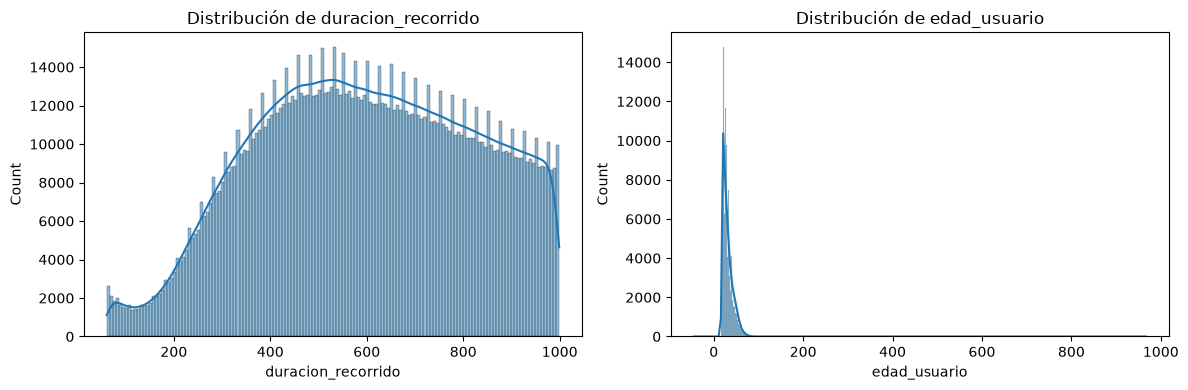

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_recorridos["duracion_recorrido"], kde=True, ax=axes[0])
axes[0].set_title("Distribución de duracion_recorrido")
sns.histplot(df_usuarios["edad_usuario"].dropna(), kde=True, ax=axes[1])
axes[1].set_title("Distribución de edad_usuario")
plt.tight_layout()
plt.show()


#### Cuantitativa discreta: viajes por usuario


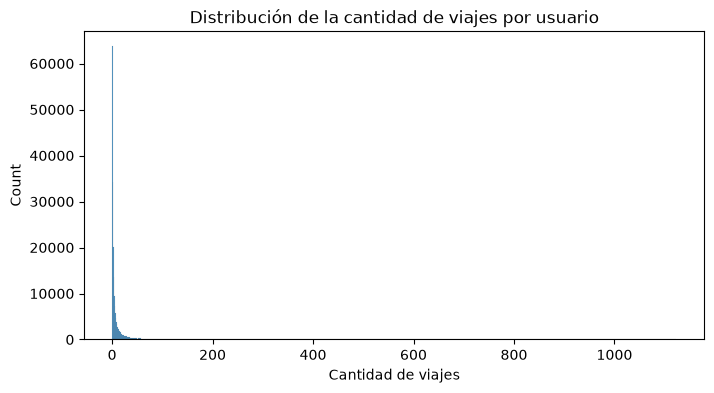

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(viajes_por_usuario, discrete=True)
plt.title("Distribución de la cantidad de viajes por usuario")
plt.xlabel("Cantidad de viajes")
plt.show()


#### Categóricas nominales: frecuencia de cada categoría



--- genero ---
genero
MALE      60.54
FEMALE    30.29
OTHER      9.17
Name: proportion, dtype: float64

--- modelo_bicicleta ---
modelo_bicicleta
FIT       63.12
ICONIC    36.88
Name: proportion, dtype: float64


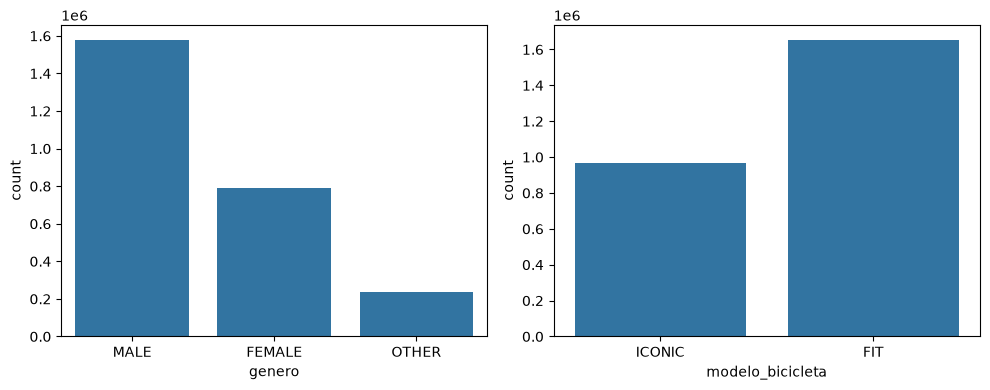

In [23]:
for col in ["genero", "modelo_bicicleta"]:
    print(f"\n--- {col} ---")
    print((df_recorridos[col].value_counts(normalize=True) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df_recorridos, x="genero", ax=axes[0], order=df_recorridos["genero"].value_counts().index)
sns.countplot(data=df_recorridos, x="modelo_bicicleta", ax=axes[1])
plt.tight_layout()
plt.show()


#### Categórica ordinal: duración agrupada (respeta el orden corto < medio < largo)


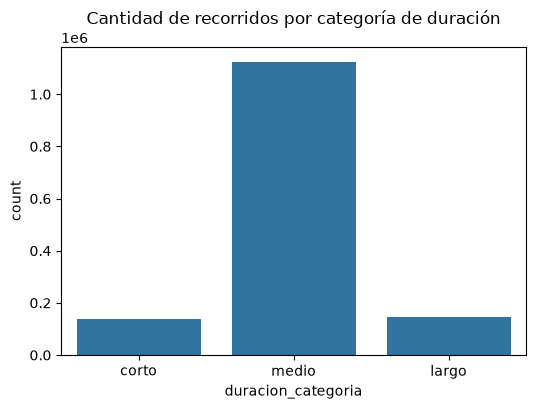

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_recorridos, x="duracion_categoria", order=etiquetas_duracion)
plt.title("Cantidad de recorridos por categoría de duración")
plt.show()


🔍 **A interpretar:** describir la forma de cada distribución (¿simétrica, sesgada hacia
duraciones largas, con varias modas?), si `viajes_por_usuario` muestra el patrón típico de
"pocos usuarios muy frecuentes, muchos usuarios ocasionales", y qué categoría de `genero`,
`modelo_bicicleta` o `duracion_categoria` concentra la mayoría de los recorridos. El punto 4
(errores, outliers y tipo de valores faltantes) se aborda en la próxima tarea.


In [25]:
### Generar un estudio de cuartiles donde variable sea duración de recorridos 

def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3


In [26]:
### Generar categorias 

def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    
    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")